# New Observation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2
from astroquery.gaia import Gaia
import numpy as np
from astropy.time import Time
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from scipy.optimize import fsolve
import astropy.units as u
from astropy.constants import G

from thejoker import JokerPrior, TheJoker, RVData
from thejoker.plot import plot_rv_curves

import pymc as pm

Status messages could not be retrieved


/Users/mac/Library/Python/3.10/lib/python/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
candidates_RVs = pd.read_csv("Data/RV_Gaia_LAMOST.csv")

In [ ]:
Desig = ['J065401.91+752725.9', 'J065401.91+752725.9', 'J065401.91+752725.9', 'J065401.91+752725.9', 'J065401.91+752725.9', 'J000556.86-012835.5', 'J000556.86-012835.5', 'J000556.86-012835.5', 'J000556.86-012835.5', 'J000556.86-012835.5']
t = [60562.75,60704.66,60716.90,60728.85,60735.96, 60605.75,60664.58,60943.64,60992.53, 61172.93]
rv = [-337.5,-324.4,-344.45,-325.58, -331.7, -110.6,-113.8,-107.1,-109.8, -118.3]
err = [1.1,0.8,0.6,0.7,0.8,0.6,0.3,0.3,0.2, 0.4]
labels = ['APF', 'APF', 'APF', 'APF', 'APF', 'APF', 'MIKE', 'MIKE', 'MIKE', 'MIKE']

df_obs_new = pd.DataFrame({
	"designation":Desig, 
	"radial_velocity": rv,
	"radial_velocity_error":err,
	"epoch": t, 
	"label": labels
})
df_RVs_all = pd.concat([candidates_RVs, df_obs_new], ignore_index = True).sort_values(by = 'designation')
df_RVs_all.to_csv("RV_all.csv")

In [4]:
df_RVs_all

,Unnamed: 0,designation,radial_velocity,radial_velocity_error,epoch,label
0,13.0,J000045.08+062941.8,-175.64000,1.150000,58794.00,LAMOST MRS
1,127.0,J000045.08+062941.8,-144.66833,2.244268,57382.84,Gaia
2,86.0,J000556.86-012835.5,-117.47000,1.010000,58452.00,LAMOST MRS
3,124.0,J000556.86-012835.5,-108.40317,1.502827,57382.84,Gaia
11,NaN,J000556.86-012835.5,-110.60000,0.600000,60605.75,APF
12,NaN,J000556.86-012835.5,-113.80000,0.300000,60664.58,MIKE
13,NaN,J000556.86-012835.5,-107.10000,0.300000,60943.64,MIKE
14,NaN,J000556.86-012835.5,-109.80000,0.200000,60992.53,MIKE
15,NaN,J000556.86-012835.5,-118.30000,0.400000,61172.93,MIKE
4,60.0,J065401.91+752725.9,-317.12000,1.190000,58437.00,LAMOST MRS


# thejoker Samples

## J000556 Sampling

In [ ]:
#INCLUDING MIKE OBSERVATIONS, APF, AND LAMOST MRS
t = [58452,59899,60605.75,60664.58,60943.64,60992.53, 61172.93]
rv = [-117.47,-116.64,-110.6,-113.8,-107.1,-109.8, -118.3] * u.km/u.s
err = [1.01,0.90,0.6,0.3,0.3,0.2,0.4] * u.km/u.s

data = RVData(t=t, rv=rv, rv_err=err)

#ORIGINAL JOKER PRIOR
#prior = JokerPrior.default(P_min=50*u.day, P_max=256*u.day,
#                           sigma_K0=50*u.km/u.s, sigma_v=25*u.km/u.s)

#CHANGE SYSTEMIC VELOCITY PRIOR TO A GAUSSIAN CENTERED AT 20 KM/S WITH SIGMA=25 KM/S
with pm.Model() as model:
#    v0 = xu.with_unit(pm.Normal('v0', 20., 25.),
#                     u.km/u.s)

	prior = JokerPrior.default(P_min=3*u.day, P_max=2000*u.day,
		sigma_K0=50*u.km/u.s,sigma_v=125*u.km/u.s)
#        pars={'v0': v0})

	
joker = TheJoker(prior)

prior_samples = prior.sample(size=1_000_000)
samples_J000556 = joker.rejection_sample(data, prior_samples)

In [82]:
samples_J000556 = samples_J000556[0]

In [85]:
samples_J000556['P'].value

array([404.21373403])

In [86]:
samples_J000556['K'].value

array([12.3896408])

## J065401 Sampling

In [ ]:
#INCLUDING MIKE OBSERVATIONS, APF, AND LAMOST MRS

t = [57382.84,58437.00,60562.75,60704.66,60716.90,60728.85, 60735.96]
rv = [-335.4,-317.1,-337.5,-324.4,-344.45,-325.58, -331.7] * u.km/u.s
err = [2.3,1.2,1.1,0.8,0.6,0.7,0.8] * u.km/u.s

data = RVData(t=t, rv=rv, rv_err=err)

#ORIGINAL JOKER PRIOR
#prior = JokerPrior.default(P_min=50*u.day, P_max=256*u.day,
#                           sigma_K0=50*u.km/u.s, sigma_v=25*u.km/u.s)

#CHANGE SYSTEMIC VELOCITY PRIOR TO A GAUSSIAN CENTERED AT 20 KM/S WITH SIGMA=25 KM/S
with pm.Model() as model:
#    v0 = xu.with_unit(pm.Normal('v0', 20., 25.),
#                     u.km/u.s)

	prior = JokerPrior.default(P_min=3*u.day, P_max=50*u.day,
		sigma_K0=38*u.km/u.s,sigma_v=125*u.km/u.s)
#        pars={'v0': v0})


joker = TheJoker(prior)

prior_samples = prior.sample(size=1_000_000)
samples_J065401 = joker.rejection_sample(data, prior_samples)

In [69]:
samples_J065401["K"]

<Quantity [-36.06039481] km / s>

In [70]:
samples_J065401["P"]

<Quantity [10.32532621] d>

# Radial Velocities plot generation

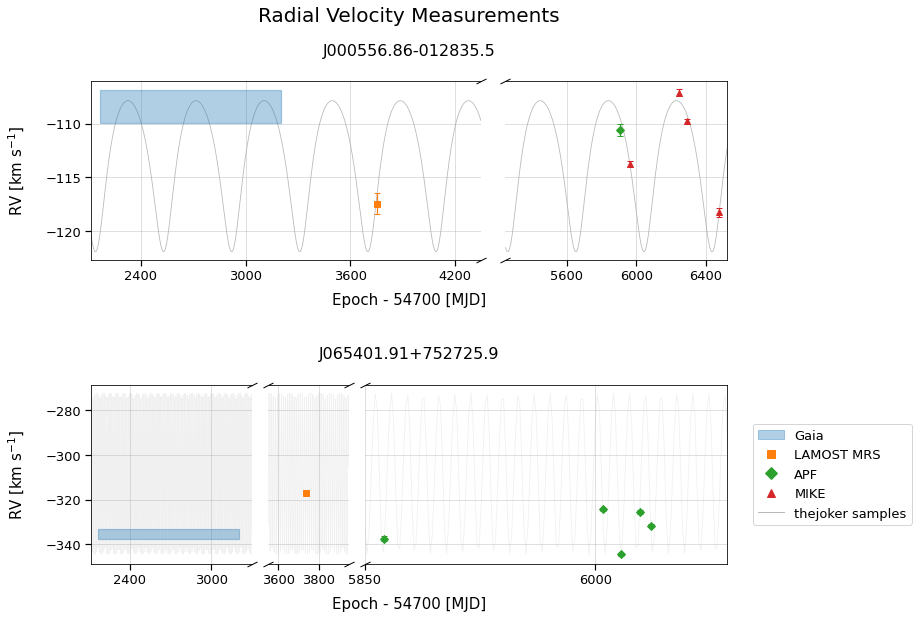

In [ ]:
plt.rcParams.update({
	"font.size": 12,
	"axes.labelsize": 14,
	"axes.titlesize": 16,
	"xtick.labelsize": 14,
	"ytick.labelsize": 14,
})

OFFSET = 54700
XLIM_PAD = 50

GAIA_START = Time("2014-07-25").mjd - OFFSET
GAIA_END = Time("2017-05-28").mjd - OFFSET

designations_to_plot = [
	"J000556.86-012835.5",
	"J065401.91+752725.9",
]

samples_dict = {
	"J000556.86-012835.5": samples_J000556,
	"J065401.91+752725.9": samples_J065401,
}

label_styles = {
	"Gaia": dict(marker="o", color="tab:blue"),
	"LAMOST MRS": dict(marker="s", color="tab:orange"),
	"APF": dict(marker="D", color="tab:green"),
	"MIKE": dict(marker="^", color="tab:red"),
}

break_ranges = {
	"J000556.86-012835.5": [
		(59000 - OFFSET, 60000 - OFFSET)
	],

	"J065401.91+752725.9": [
		(3250, 3600),
		(3900, 5900),
	],
}

fig = plt.figure(figsize=(13, 13))

LEFT = 0.10
RIGHT = 0.78
panel_center_x = 0.5 * (LEFT + RIGHT)

outer_gs = fig.add_gridspec(
	3, 1,
	left=LEFT,
	right=RIGHT,
	bottom=0.08,
	top=0.92,
	hspace=0.70,
)

legend_handles = {}


def get_x_segments(xmin, xmax, breaks, pad=XLIM_PAD):
	breaks = sorted(breaks)
	segments = []
	start = xmin

	for b0, b1 in breaks:
		if start < b0:
			segments.append((start, b0))
		start = b1

	if start < xmax:
		segments.append((start, xmax))

	return [(a - pad, b + pad) for a, b in segments]


def add_break_marks(ax_left, ax_right, d=0.5):
	kwargs = dict(
		marker=[(-1, -d), (1, d)],
		markersize=10,
		linestyle="none",
		color="k",
		mec="k",
		mew=1,
		clip_on=False,
	)

	ax_left.plot([1], [0], transform=ax_left.transAxes, **kwargs)
	ax_left.plot([1], [1], transform=ax_left.transAxes, **kwargs)

	ax_right.plot([0], [0], transform=ax_right.transAxes, **kwargs)
	ax_right.plot([0], [1], transform=ax_right.transAxes, **kwargs)


def plot_one_star(desig, subplot_spec):

	label_ax = fig.add_subplot(subplot_spec, frameon=False)
	label_ax.set_xticks([])
	label_ax.set_yticks([])
	label_ax.set_xlabel(
		f"Epoch - {OFFSET} [MJD]",
		labelpad=24,
		fontsize=15,
	)
	label_ax.set_ylabel(
		r"RV [km s$^{-1}$]",
		labelpad=42,
		fontsize=15,
	)
	label_ax.set_zorder(0)

	df_star = (
		df_RVs_all[df_RVs_all["designation"] == desig]
		.sort_values("epoch")
		.copy()
	)
	
	label_ax.xaxis.set_label_coords(0.5, -0.18)
	label_ax.yaxis.set_label_coords(-0.10, 0.5)

	x = df_star["epoch"].to_numpy() - OFFSET

	xmin = min(x.min(), GAIA_START)
	xmax = max(x.max(), GAIA_END)

	breaks = break_ranges.get(desig, [])

	if len(breaks) == 0:
		x_segments = [(xmin - XLIM_PAD, xmax + XLIM_PAD)]
	else:
		x_segments = get_x_segments(xmin, xmax, breaks, pad=XLIM_PAD)

	if desig == "J065401.91+752725.9":
		width_ratios = [2.0, 1.0, 4.5]
	else:
		width_ratios = [
			max(seg[1] - seg[0], 1)
			for seg in x_segments
		]

	inner_gs = subplot_spec.subgridspec(
		1,
		len(x_segments),
		wspace=0.08,
		width_ratios=width_ratios,
	)

	axes = []

	for j, xlim in enumerate(x_segments):

		ax = fig.add_subplot(
			inner_gs[0, j],
			sharey=axes[0] if axes else None,
		)

		ax.set_xlim(*xlim)

		if desig == "J065401.91+752725.9":
			ax.xaxis.set_major_locator(MaxNLocator(nbins=2, integer=True))
		else:
			ax.xaxis.set_major_locator(MaxNLocator(nbins=4, integer=True))

		ax.tick_params(
			axis="both",
			which="major",
			labelsize=13,
			length=6,
			width=1.2,
		)

		axes.append(ax)

		if j > 0:
			ax.tick_params(left=False, labelleft=False)
			ax.spines["left"].set_visible(False)

		if j < len(x_segments) - 1:
			ax.spines["right"].set_visible(False)

	if desig in samples_dict:

		these_samples = samples_dict[desig]

		rng = np.random.default_rng(42)
		n_plot = min(100, len(these_samples))

		idx = rng.choice(
			len(these_samples),
			size=n_plot,
			replace=False,
		)

		chosen_samples = these_samples[idx]

		t_grid_shifted = np.linspace(
			xmin - XLIM_PAD,
			xmax + XLIM_PAD,
			3000,
		)

		t_grid = t_grid_shifted + OFFSET

		t_grid_time = Time(
			t_grid,
			format="mjd",
			scale="tcb",
		)

		model_rv = np.zeros((n_plot, len(t_grid)))

		for k in range(n_plot):
			orbit = chosen_samples.get_orbit(k)

			model_rv[k] = (
				orbit
				.radial_velocity(t_grid_time)
				.to(u.km / u.s)
				.value
			)

		for ax, xlim in zip(axes, x_segments):

			mask = (
				(t_grid_shifted >= xlim[0])
				&
				(t_grid_shifted <= xlim[1])
			)

			if desig == "J000556.86-012835.5":
				joker_alpha = 0.50
			elif desig == "J065401.91+752725.9":
				joker_alpha = 0.10
			else:
				joker_alpha = 0.10

			for k in range(n_plot):
				ax.plot(
					t_grid_shifted[mask],
					model_rv[k][mask],
					color="0.45",
					alpha=joker_alpha,
					linewidth=0.8,
					zorder=1,
				)

	for ax in axes:

		xlim = ax.get_xlim()

		for label, df_label in df_star.groupby("label"):

			style = label_styles.get(
				label,
				dict(marker="o", color="tab:gray"),
			)

			if label == "Gaia":

				for _, row in df_label.iterrows():

					y_center = row["radial_velocity"]
					yerr = row["radial_velocity_error"]

					rect_x0 = max(GAIA_START, xlim[0])
					rect_x1 = min(GAIA_END, xlim[1])

					if rect_x1 <= rect_x0:
						continue

					rect = Rectangle(
						(rect_x0, y_center - yerr),
						rect_x1 - rect_x0,
						2 * yerr,
						facecolor=style["color"],
						edgecolor=style["color"],
						alpha=0.35,
						linewidth=1.2,
						zorder=4,
					)

					ax.add_patch(rect)

				if "Gaia" not in legend_handles:
					legend_handles["Gaia"] = Patch(
						facecolor=style["color"],
						edgecolor=style["color"],
						alpha=0.35,
						label="Gaia",
					)

				continue

			x_label = df_label["epoch"].to_numpy() - OFFSET

			visible = (
				(x_label >= xlim[0])
				&
				(x_label <= xlim[1])
			)

			df_plot = df_label[visible].copy()
			x_plot = df_plot["epoch"].to_numpy() - OFFSET

			if len(df_plot) == 0:
				continue

			ax.errorbar(
				x_plot,
				df_plot["radial_velocity"],
				yerr=df_plot["radial_velocity_error"],
				fmt=style["marker"],
				color=style["color"],
				ecolor=style["color"],
				markersize=6,
				capsize=3,
				linestyle="none",
				elinewidth=1.2,
				zorder=5,
			)

			if label not in legend_handles:
				legend_handles[label] = Line2D(
					[0],
					[0],
					marker=style["marker"],
					color=style["color"],
					markerfacecolor=style["color"],
					linestyle="none",
					markersize=8,
					label=label,
				)

		ax.grid(alpha=0.5)

	for j in range(len(axes) - 1):
		add_break_marks(axes[j], axes[j + 1])

	x0 = axes[0].get_position().x0
	x1 = axes[-1].get_position().x1
	y1 = axes[0].get_position().y1

	fig.text(
		0.5 * (x0 + x1),
		y1 + 0.025,
		desig,
		ha="center",
		va="bottom",
		fontsize=16,
	)


for i, desig in enumerate(designations_to_plot):
	plot_one_star(desig, outer_gs[i, 0])


legend_handles["TheJoker samples"] = Line2D(
	[0],
	[0],
	color="0.45",
	linewidth=1.0,
	alpha=0.5,
	label="thejoker samples",
)

fig.legend(
	handles=list(legend_handles.values()),
	loc="center left",
	bbox_to_anchor=(0.8, 0.5),
	frameon=True,
	fontsize=13,
	title_fontsize=12,
)

fig.text(
	panel_center_x,
	1.0,
	"Radial Velocity Measurements",
	ha="center",
	va="top",
	fontsize=20,
)

plt.savefig(
	"radial_velocity_panels_with_joker_curves.png",
	dpi=300,
	bbox_inches="tight",
)

plt.show()

# Binary Mass Estimation

In [90]:
def calculate_binary_mass(period, velocity_amplitude, eccentricity, inclination, M1):
	P = (period * u.day).to(u.s)
	K = np.abs((velocity_amplitude * u.km / u.s).to(u.m / u.s))
	e = eccentricity
	
	numerator = P * K**3 * (1 - e**2)**(3/2)
	denominator = 2 * np.pi * G

	f_m = ((numerator / denominator).to(u.M_sun)).value

	sin_i = np.sin(np.radians(inclination))

	def equation(M2):
		return (M2**3 * sin_i**3) / (M1 + M2)**2 - f_m

	M2_guess = 0.5

	# Solve
	M2_solution = fsolve(equation, M2_guess)[0]

	return M2_solution

In [97]:
samples = samples_J000556
M2_list = []
for i in range(len(samples)):
	period = samples[i]['P'].value
	amplitude = samples[i]['K'].value
	ecc = samples[i]['e'].value
	inc = 45
	
	for M1 in [0.8, 1.0]:
		M2 = calculate_binary_mass(period, amplitude, ecc, inc, M1)
		M2_list.append(M2)

In [98]:
np.mean(M2_list)

0.5375880387425621

In [99]:
M2_list[0] - np.mean(M2_list)

-0.033279877046302975